In [2]:
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, ImageFormatOption, PdfFormatOption

from cells2table.docling import CustomDoclingTableStructureOptions

In [3]:
import logging

# Get the root logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Only add handler if it doesn't exist
if not logger.handlers:
    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s\t%(levelname)s\t%(name)s: %(message)s')
    ch.setFormatter(formatter)
    logger.addHandler(ch)

# Test logging
logger.info("This will appear only once")

2026-05-04 00:35:20,843	INFO	root: This will appear only once


In [4]:
# from docling.datamodel.pipeline_options import TableStructureOptions, TableStructureV2Options

pipeline_options = PdfPipelineOptions(
    allow_external_plugins=True,
    table_structure_options=CustomDoclingTableStructureOptions(),
    do_ocr=True,
    # table_structure_options=TableStructureV2Options(),
    generate_page_images=True,
)

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options),
        InputFormat.IMAGE: ImageFormatOption(pipeline_options=pipeline_options),
    }
)

result = converter.convert("../example_table.png")
# result = converter.convert(
#     "/home/joao/Projetos/Desenvolve/repo/instructional_agents/tests/data/pdf/07.pdf",
# )
print(result.document.export_to_markdown())

2026-05-04 00:35:20,876	INFO	docling.datamodel.document: detected formats: [<InputFormat.IMAGE: 'image'>]
2026-05-04 00:35:20,896	INFO	docling.document_converter: Going to convert document batch...
2026-05-04 00:35:20,897	INFO	docling.document_converter: Initializing pipeline for StandardPdfPipeline with options hash 2cf08d88af43bffbfb79e57a0d16f6bc
2026-05-04 00:35:20,913	INFO	docling.models.factories.base_factory: Loading plugin 'docling_defaults'
2026-05-04 00:35:20,917	INFO	docling.models.factories: Registered picture descriptions: ['picture_description_vlm_engine', 'vlm', 'api']
2026-05-04 00:35:20,932	INFO	docling.models.factories.base_factory: Loading plugin 'docling_defaults'
2026-05-04 00:35:20,946	INFO	docling.models.factories: Registered ocr engines: ['auto', 'easyocr', 'kserve_v2_ocr', 'ocrmac', 'rapidocr', 'tesserocr', 'tesseract']
2026-05-04 00:35:21,103	INFO	docling.utils.accelerator_utils: Accelerator device: 'cpu'
[INFO] 2026-05-04 00:35:21,128 [RapidOCR] base.py:22: U

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

2026-05-04 00:35:28,618	INFO	docling.models.factories.base_factory: Loading plugin 'docling_defaults'
2026-05-04 00:35:28,622	INFO	docling.models.factories.base_factory: Loading plugin 'cells2table'
2026-05-04 00:35:28,622	INFO	docling.models.factories: Registered table structure engines: ['docling_tableformer', 'docling_tableformer_v2', 'granite_vision_table', 'cells2table']
2026-05-04 00:35:28,623	INFO	cells2table.utils.download: Downloading HF repo jspast/paddlepaddle-table-models-onnx
2026-05-04 00:35:28,822	INFO	httpx: HTTP Request: GET https://huggingface.co/api/models/jspast/paddlepaddle-table-models-onnx/revision/main "HTTP/1.1 200 OK"
2026-05-04 00:35:28,825	INFO	cells2table.utils.download: Downloading HF repo jspast/paddlepaddle-table-models-onnx
2026-05-04 00:35:28,985	INFO	httpx: HTTP Request: GET https://huggingface.co/api/models/jspast/paddlepaddle-table-models-onnx/revision/main "HTTP/1.1 200 OK"
2026-05-04 00:35:28,993	INFO	cells2table.utils.download: Downloading HF rep

<!-- image -->

<!-- image -->

<!-- image -->

<!-- image -->

<!-- image -->

| ITEM   | ATIVIDADES                                                                                                                                                                                                    | ILUSTRACAO   |
|--------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------|
|        | Gerar PC (Pedido de Compras): Atividade anterior - Processo de Compras, PC (Pedido de Compras emitido diretamente para fornecedor, (atraves do sistema informatizado "Integra").                              |              |
| 2.     | Aceite dopedido: Fornecedor aceita o pedido de compras emitido pela matriz / filial e comeca o carregamento dos itens descritosetratados durante opedido.                                                     |

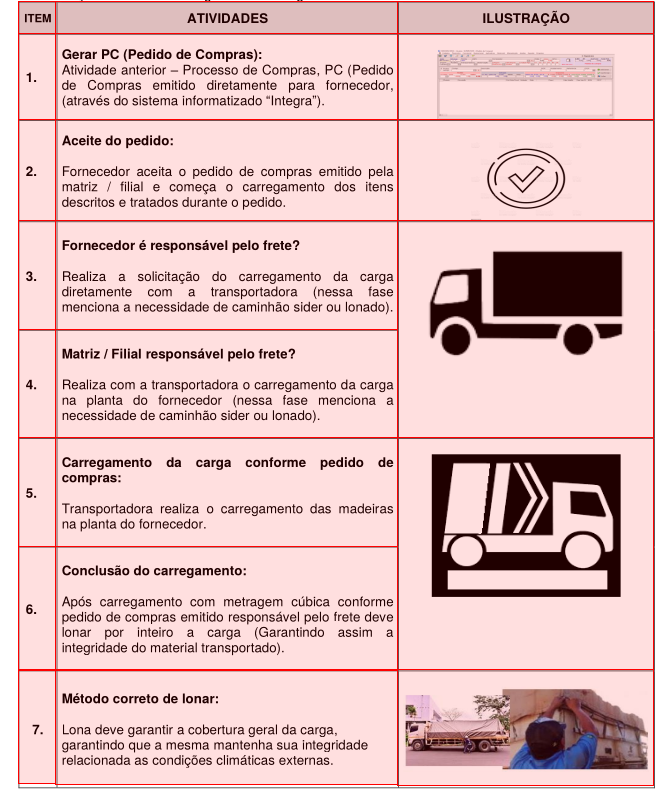

In [7]:
from IPython.display import display
from docling_core.transforms.visualizer.table_visualizer import TableVisualizer
table_visualizer = TableVisualizer()
pred_img = table_visualizer.get_visualization(doc=result.document)[1]
display(pred_img)

In [10]:
from docling_core.types.doc.labels import DocItemLabel

layout = result.pages[0].predictions.layout
if layout is None:
    raise ValueError("F")

table_clusters = [
    cluster
    for cluster in layout.clusters
    if cluster.label in [DocItemLabel.TABLE, DocItemLabel.DOCUMENT_INDEX]
]

for c in table_clusters[0].cells:
    print(c.text)

ITEM
ATIVIDADES
ILUSTRACAO
Gerar PC (Pedido de Compras):
Atividade anterior - Processo de Compras, PC (Pedido
de Compras emitido diretamente para fornecedor,
(atraves do sistema informatizado "Integra").
Aceite dopedido:
2.
Fornecedor aceita o pedido de compras emitido pela
matriz / filial e comeca o carregamento dos itens
descritosetratados durante opedido.
Fornecedor é responsavel pelo frete?
3.
Realiza a solicitacao do carregamento da carga
diretamentecomatransportadora(nessafase
mencionaanecessidade de caminhaosideroulonado).
Matriz/ Filial responsavel pelo frete?
4.
Realiza com a transportadora o carregamento da carga
na planta do fornecedor(nessa fasemenciona a
necessidade de caminhao sider ou lonado).
Carregamento da carga conforme pedido de
compras:
5.
Transportadorarealizaocarregamentodasmadeiras
na planta dofornecedor.
Conclusao do carregamento:
Apos carregamento com metragem cubica conforme
6.
pedidodecomprasemitidoresponsavelpelofrete deve
lonar por inteiro a carga (Garanti